In [4]:
from google.colab import files
from IPython.display import Image

In [5]:
uploaded = files.upload()

Saving flower.png to flower.png


In [6]:
Image ('flower.png')

Output hidden; open in https://colab.research.google.com to view.

In [7]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [8]:
from PIL import Image
# display image in colab
image_colored = Image . open ("flower.png" )
display ( image_colored )

Output hidden; open in https://colab.research.google.com to view.

In [17]:
from PIL import Image
from IPython.display import display

image_colored = Image.open("flower.png")
print(image_colored.mode)

display(image_colored)

Output hidden; open in https://colab.research.google.com to view.

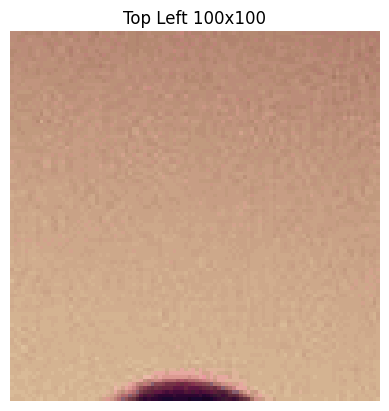

In [21]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open("flower.png").convert("RGB")
img_array = np.array(img)

top_left = img_array[0:100, 0:100, :]

plt.imshow(top_left)
plt.title("Top Left 100x100")
plt.axis("off")
plt.show()

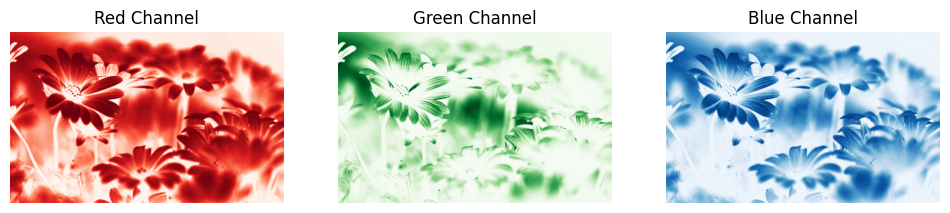

In [22]:
R = img_array[:,:,0]
G = img_array[:,:,1]
B = img_array[:,:,2]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap="Reds")
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap="Greens")
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap="Blues")
plt.title("Blue Channel")
plt.axis("off")

plt.show()

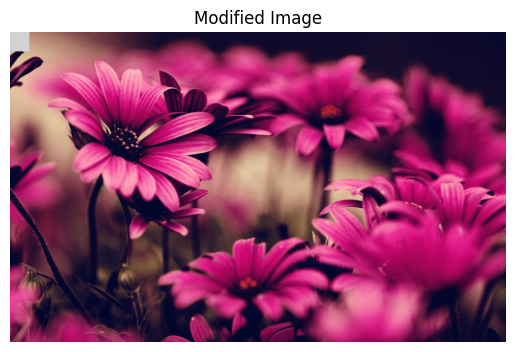

In [23]:
modified = img_array.copy()

modified[0:100,0:100] = 210

plt.imshow(modified)
plt.title("Modified Image")
plt.axis("off")
plt.show()

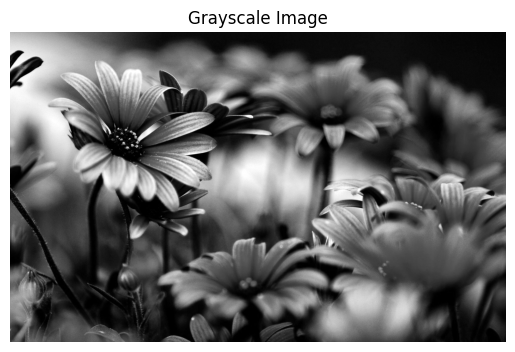

In [25]:
gray_img = Image.open("flower.png").convert("L")
gray_array = np.array(gray_img)

plt.imshow(gray_array, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

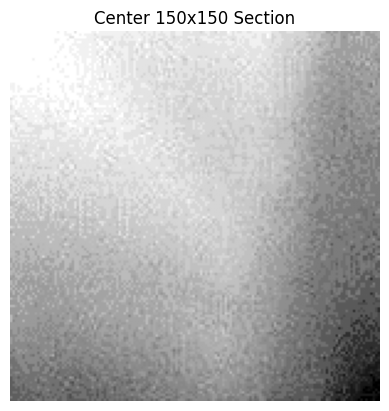

In [26]:
h, w = gray_array.shape

center_crop = gray_array[h//2-75:h//2+75 , w//2-75:w//2+75]

plt.imshow(center_crop, cmap="gray")
plt.title("Center 150x150 Section")
plt.axis("off")
plt.show()

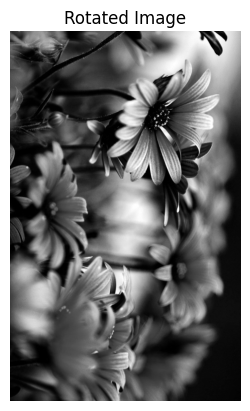

In [27]:
rotated = gray_img.rotate(-90, expand=True)

plt.imshow(rotated, cmap="gray")
plt.title("Rotated Image")
plt.axis("off")
plt.show()

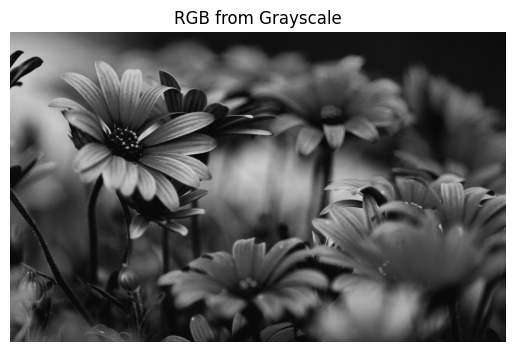

In [29]:
rgb = np.stack((gray_array,)*3, axis=-1)

plt.imshow(rgb)
plt.title("RGB from Grayscale")
plt.axis("off")
plt.show()

In [31]:
img = Image.open("flower.png").convert("L")
img_array = np.array(img)

In [32]:
mean = np.mean(img_array, axis=0)
centered = img_array - mean

In [33]:
cov_matrix = np.cov(centered, rowvar=False)

In [34]:
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

In [35]:
idx = np.argsort(eigen_values)[::-1]

eigen_values = eigen_values[idx]
eigen_vectors = eigen_vectors[:,idx]

In [36]:
k = 50
PC = eigen_vectors[:, :k]

In [37]:
compressed = np.dot(centered, PC)

In [38]:
reconstructed = np.dot(compressed, PC.T) + mean

In [40]:
reconstructed = np.real(reconstructed)

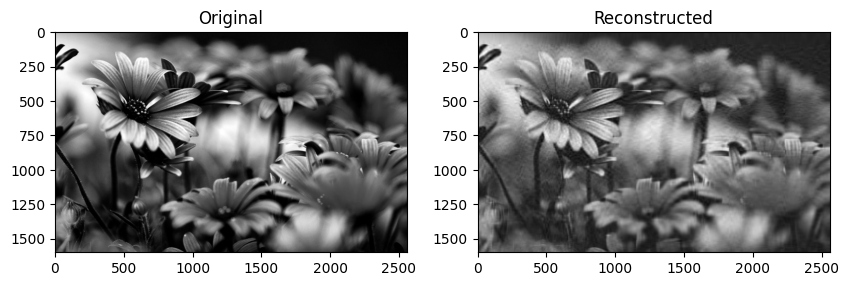

In [41]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_array, cmap="gray")
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(reconstructed, cmap="gray")
plt.title("Reconstructed")

plt.show()